# Lesson 10: Cypher Path Queries

## Learning Objectives

By the end of this lesson, you will:
- **Master path syntax**: Write queries using named paths, variable-length paths (`-[*]->`, `-[*1..3]->`)
- **Detect cycles**: Find circular references and self-loops in graphs
- **Aggregate over paths**: Use `reduce()` to calculate costs, weights, and other metrics along paths
- **Optimize queries**: Use `EXPLAIN`/`PROFILE` to understand and improve query performance
- **Real-world patterns**: Model approval workflows, dependencies, and recommendation systems

## Prerequisites
- Lesson 09: Neo4j Property Graph Modeling (document_policy graph must be loaded)
- Neo4j running on localhost:7687

## Dataset: Document Policy Graph
- **100 documents** linked by 290 **REFERENCES** relationships (weighted 1-3)
- **10 owners** and **8 teams** for approval workflows
- **15 topics** for categorization
- **Total: 133 nodes, 690 relationships**

## Setup: Imports and Neo4j Connection

In [42]:
# Import required libraries
from neo4j import GraphDatabase
import pandas as pd
from pathlib import Path
import re
import matplotlib.pyplot as plt
import json

print("✓ Imports successful")

✓ Imports successful


In [43]:
# Neo4j connection parameters
NEO4J_URI = "bolt://localhost:7687"
NEO4J_USERNAME = "neo4j"
NEO4J_PASSWORD = "your_password_here"

# Create driver
try:
    driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
    print(f"✓ Neo4j connected to {NEO4J_URI}")
except Exception as e:
    print(f"✗ Connection failed: {e}")
    driver = None

✓ Neo4j connected to bolt://localhost:7687


In [44]:
# Health check
if driver:
    try:
        with driver.session() as session:
            result = session.run("RETURN 'Connected!' as msg")
            msg = result.single()[0]
            print(f"✓ {msg} - Neo4j is responding")
    except Exception as e:
        print(f"✗ Health check failed: {e}")
else:
    print("✗ Driver not initialized")

✓ Connected! - Neo4j is responding


In [45]:
# Set up data paths
notebook_dir = Path.cwd()
if 'notebooks' not in str(notebook_dir):
    notebook_dir = Path.cwd() / 'notebooks'
    if not notebook_dir.exists():
        notebook_dir = Path('/home/marek/Apps/graph-analysis-course/notebooks')

workspace_root = notebook_dir.parent if 'notebooks' in str(notebook_dir) else Path.cwd()
data_dir = workspace_root / 'data' / 'seed' / 'document_policy'
cypher_dir = workspace_root / 'cypher'

print(f"Data directory: {data_dir}")
print(f"Data directory exists: {data_dir.exists()}")

Data directory: /home/marek/Apps/graph-analysis-course/data/seed/document_policy
Data directory exists: True


In [46]:
# Verify document_policy graph is loaded
if driver:
    with driver.session() as session:
        # Count nodes by type
        result = session.run("""
        MATCH (n)
        RETURN labels(n)[0] as node_type, count(n) as count
        ORDER BY node_type
        """)
        
        print("=== NODE COUNTS ===")
        node_counts = {}
        total = 0
        for record in result:
            node_type = record['node_type']
            count = record['count']
            node_counts[node_type] = count
            total += count
            print(f"{node_type:15}: {count:3}")
        print(f"{'Total':15}: {total:3}")
        
        # Count relationships by type
        result = session.run("""
        MATCH ()-[r]->()
        RETURN type(r) as rel_type, count(r) as count
        ORDER BY rel_type
        """)
        
        print("\n=== RELATIONSHIP COUNTS ===")
        rel_counts = {}
        total_rels = 0
        for record in result:
            rel_type = record['rel_type']
            count = record['count']
            rel_counts[rel_type] = count
            total_rels += count
            print(f"{rel_type:15}: {count:3}")
        print(f"{'Total':15}: {total_rels:3}")

=== NODE COUNTS ===
Document       : 100
Owner          :  10
Team           :   8
Topic          :  15
Total          : 133

=== RELATIONSHIP COUNTS ===
ABOUT          : 100
OWNED_BY       :  91
REFERENCES     : 290
USES           : 200
Total          : 681


In [47]:
# Helper function: pretty-print paths from Cypher results
def print_paths(results, max_rows=10):
    """Pretty print path results from Neo4j query."""
    if not results:
        print("No results")
        return
    
    for i, record in enumerate(results[:max_rows]):
        print(f"\n--- Result {i+1} ---")
        for key, value in record.items():
            if hasattr(value, '__iter__') and not isinstance(value, str):
                print(f"{key}: {list(value)}")
            else:
                print(f"{key}: {value}")

def run_query(driver, query):
    """Run a Cypher query and return results as list of dicts."""
    with driver.session() as session:
        result = session.run(query)
        return [dict(record) for record in result]

print("✓ Helper functions defined: print_paths(), run_query()")

✓ Helper functions defined: print_paths(), run_query()


---
# Part 1: Path Basics

## Concept: Named Paths and Extraction Functions

In Cypher, a **path** is a sequence of alternating nodes and relationships:
- `p = (node1)-[relationship]->(node2)` — stores the entire path in variable `p`
- `nodes(p)` — extracts all nodes from the path as a list
- `relationships(p)` — extracts all relationships as a list  
- `length(p)` — returns the number of hops (relationships) in the path

**Example Use Case**: Finding all documents that reference each other, tracing the complete chain.

In [48]:
# Simple direct path query
if driver:
    query = """
    MATCH p=(d1:Document {document_id: 'DOC_0001'})-[:REFERENCES]->(d2:Document)
    RETURN d1.document_id as source, d2.document_id as target, d2.status
    LIMIT 10
    """
    results = run_query(driver, query)
    df = pd.DataFrame(results)
    print(f"Documents directly referenced by DOC_0001:")
    print(df.to_string(index=False))

Documents directly referenced by DOC_0001:
  source   target  d2.status
DOC_0001 DOC_0016     active
DOC_0001 DOC_0034     active
DOC_0001 DOC_0058     active
DOC_0001 DOC_0011     active
DOC_0001 DOC_0005 deprecated


In [49]:
# Named path with node and relationship extraction
if driver:
    query = """
    MATCH p=(d1:Document {document_id: 'DOC_0001'})-[:REFERENCES*1..2]->(d2:Document)
    RETURN 
        d1.document_id as source,
        d2.document_id as target,
        length(p) as path_length,
        [n IN nodes(p) | n.document_id] as all_nodes_in_path
    ORDER BY path_length
    LIMIT 5
    """
    results = run_query(driver, query)
    print("\nPaths from DOC_0001 (1-2 hops):")
    for i, r in enumerate(results):
        print(f"\n{i+1}. {r['source']} -> {r['target']}")
        print(f"   Hops: {r['path_length']}")
        print(f"   Full chain: {' -> '.join(r['all_nodes_in_path'])}")


Paths from DOC_0001 (1-2 hops):

1. DOC_0001 -> DOC_0005
   Hops: 1
   Full chain: DOC_0001 -> DOC_0005

2. DOC_0001 -> DOC_0034
   Hops: 1
   Full chain: DOC_0001 -> DOC_0034

3. DOC_0001 -> DOC_0011
   Hops: 1
   Full chain: DOC_0001 -> DOC_0011

4. DOC_0001 -> DOC_0058
   Hops: 1
   Full chain: DOC_0001 -> DOC_0058

5. DOC_0001 -> DOC_0016
   Hops: 1
   Full chain: DOC_0001 -> DOC_0016


In [50]:
# Extract relationships from path (access their properties like weight)
if driver:
    query = """
    MATCH p=(d1:Document {document_id: 'DOC_0002'})-[:REFERENCES*1..3]->(d2:Document)
    RETURN 
        d1.document_id as source,
        d2.document_id as target,
        length(p) as hops,
        [r IN relationships(p) | r.weight] as weights_on_path
    LIMIT 5
    """
    results = run_query(driver, query)
    print("\nPaths with relationship weights:")
    for r in results:
        print(f"{r['source']} -> {r['target']} ({r['hops']} hops): weights = {r['weights_on_path']}")


Paths with relationship weights:
DOC_0002 -> DOC_0092 (1 hops): weights = [4]
DOC_0002 -> DOC_0089 (2 hops): weights = [4, 3]
DOC_0002 -> DOC_0071 (3 hops): weights = [4, 3, 1]
DOC_0002 -> DOC_0099 (3 hops): weights = [4, 3, 1]
DOC_0002 -> DOC_0086 (3 hops): weights = [4, 3, 1]


In [51]:
# QUICK EXERCISE 1: Find all documents reachable from DOC_0001 in EXACTLY 2 reference hops
# Return the source, target, and the intermediate document

print("EXERCISE 1: Find all documents reachable from DOC_0001 in exactly 2 REFERENCES hops")
print("Include: source, intermediate document, target, and all 3 documents in sequence.\n")

if driver:
    # SOLUTION:
    query = """
    MATCH p=(source:Document {document_id: 'DOC_0001'})-[:REFERENCES]->(mid:Document)-[:REFERENCES]->(target:Document)
    RETURN 
        source.document_id as source_doc,
        mid.document_id as intermediate_doc,
        target.document_id as target_doc,
        target.status
    ORDER BY target.document_id
    LIMIT 15
    """
    results = run_query(driver, query)
    df = pd.DataFrame(results)
    print("Solution:")
    print(df.to_string(index=False))
    print(f"\nFound {len(results)} documents reachable in 2 hops from DOC_0001")

EXERCISE 1: Find all documents reachable from DOC_0001 in exactly 2 REFERENCES hops
Include: source, intermediate document, target, and all 3 documents in sequence.

Solution:
source_doc intermediate_doc target_doc target.status
  DOC_0001         DOC_0034   DOC_0007        active
  DOC_0001         DOC_0011   DOC_0016        active
  DOC_0001         DOC_0058   DOC_0017        active
  DOC_0001         DOC_0058   DOC_0039         draft
  DOC_0001         DOC_0016   DOC_0051        active
  DOC_0001         DOC_0034   DOC_0052        active
  DOC_0001         DOC_0058   DOC_0055        active
  DOC_0001         DOC_0058   DOC_0063         draft
  DOC_0001         DOC_0016   DOC_0069        active
  DOC_0001         DOC_0058   DOC_0075        active
  DOC_0001         DOC_0011   DOC_0081         draft
  DOC_0001         DOC_0016   DOC_0090        active

Found 12 documents reachable in 2 hops from DOC_0001


---
# Part 2: Variable-Length Paths

## Concept: Traversing Any Depth

**Variable-length path syntax**:
- `-[*]->` — unbounded: traverse any number of relationships (careful: can be expensive!)
- `-[*1..3]->` — bounded: traverse 1 to 3 relationships (recommended for performance)
- `-[*2..5]->` — specific bounds: start at 2, end at 5 hops
- `-[*0..3]->` — optional: includes direct connection (0 hops) plus up to 3 hops

**Why bounds matter**: Unbounded traversals can hit millions of paths in large graphs. Always use bounds in production!

**Real-world example**: Finding approval chains, recommendation paths, or ripple effects of failures in systems.

In [52]:
# Unbounded path example (use with caution!)
# NOTE: Unbounded queries can hang on large graphs. Using bounded version instead.
if driver:
    query = """
    MATCH p=(d1:Document {document_id: 'DOC_0001'})-[:REFERENCES*1..10]->(d2:Document)
    RETURN DISTINCT d2.document_id as reachable_doc, 
           min(length(p)) as min_hops,
           max(length(p)) as max_hops
    ORDER BY min_hops, reachable_doc
    LIMIT 20
    """
    results = run_query(driver, query)
    df = pd.DataFrame(results)
    print("All documents reachable from DOC_0001 (bounded to 10 hops):")
    print(df.to_string(index=False))
    print(f"\nNote: Found {len(results)} unique documents (using 1-10 hop limit for safety)")
    print("⚠ Unbounded paths (-[*]->) can hang on large graphs - always use bounds!")

All documents reachable from DOC_0001 (bounded to 10 hops):
reachable_doc  min_hops  max_hops
     DOC_0005         1        10
     DOC_0011         1        10
     DOC_0016         1        10
     DOC_0034         1        10
     DOC_0058         1        10
     DOC_0007         2        10
     DOC_0017         2        10
     DOC_0039         2        10
     DOC_0051         2        10
     DOC_0052         2        10
     DOC_0055         2        10
     DOC_0063         2        10
     DOC_0069         2        10
     DOC_0075         2        10
     DOC_0081         2        10
     DOC_0090         2        10
     DOC_0001         3        10
     DOC_0004         3        10
     DOC_0008         3        10
     DOC_0018         3        10

Note: Found 20 unique documents (using 1-10 hop limit for safety)
⚠ Unbounded paths (-[*]->) can hang on large graphs - always use bounds!


In [53]:
# Bounded path example (much safer!)
if driver:
    query = """
    MATCH p=(d1:Document {document_id: 'DOC_0002'})-[:REFERENCES*1..3]->(d2:Document)
    RETURN d1.document_id as source, d2.document_id as target, 
           length(p) as path_length,
           count(*) as num_different_paths
    ORDER BY path_length, target
    LIMIT 20
    """
    results = run_query(driver, query)
    df = pd.DataFrame(results)
    print("Documents reachable from DOC_0002 in 1-3 hops (grouped by path length):")
    print(df.to_string(index=False))

Documents reachable from DOC_0002 in 1-3 hops (grouped by path length):
  source   target  path_length  num_different_paths
DOC_0002 DOC_0092            1                    1
DOC_0002 DOC_0030            2                    1
DOC_0002 DOC_0054            2                    1
DOC_0002 DOC_0058            2                    1
DOC_0002 DOC_0072            2                    1
DOC_0002 DOC_0089            2                    1
DOC_0002 DOC_0098            2                    1
DOC_0002 DOC_0004            3                    1
DOC_0002 DOC_0017            3                    2
DOC_0002 DOC_0019            3                    1
DOC_0002 DOC_0021            3                    1
DOC_0002 DOC_0038            3                    1
DOC_0002 DOC_0039            3                    1
DOC_0002 DOC_0055            3                    1
DOC_0002 DOC_0060            3                    1
DOC_0002 DOC_0062            3                    1
DOC_0002 DOC_0063            3              

In [54]:
# Filter paths by length during traversal
if driver:
    query = """
    MATCH p=(d1:Document {document_id: 'DOC_0003'})-[:REFERENCES*2..4]->(d2:Document)
    RETURN d1.document_id as source, d2.document_id as target, 
           length(p) as path_length,
           count(*) as num_paths
    ORDER BY path_length DESC, num_paths DESC
    LIMIT 10
    """
    results = run_query(driver, query)
    df = pd.DataFrame(results)
    print("\nDocuments reachable from DOC_0003 in 2-4 hops:")
    print(df.to_string(index=False))


Documents reachable from DOC_0003 in 2-4 hops:
  source   target  path_length  num_paths
DOC_0003 DOC_0075            4          1
DOC_0003 DOC_0059            4          1
DOC_0003 DOC_0040            4          1
DOC_0003 DOC_0024            4          1
DOC_0003 DOC_0038            4          1
DOC_0003 DOC_0005            4          1
DOC_0003 DOC_0072            4          1
DOC_0003 DOC_0073            4          1
DOC_0003 DOC_0074            4          1
DOC_0003 DOC_0052            4          1


In [55]:
# Filter by node count in path
if driver:
    query = """
    MATCH p=(d1:Document)-[:REFERENCES*2..4]->(d2:Document)
    WHERE d1.document_id = 'DOC_0005'
    RETURN d1.document_id as source, d2.document_id as target, 
           length(p) as hops,
           size(nodes(p)) as num_nodes_in_path,
           [n IN nodes(p) | n.document_id] as node_sequence
    ORDER BY hops, target
    LIMIT 8
    """
    results = run_query(driver, query)
    print("\nPaths from DOC_0005 (2-4 hops) showing full node sequence:")
    for i, r in enumerate(results):
        print(f"\n{i+1}. {r['source']} → {r['target']} ({r['hops']} hops)")
        print(f"   Nodes: {' → '.join(r['node_sequence'])}")


Paths from DOC_0005 (2-4 hops) showing full node sequence:


In [56]:
# Multiple relationship types in same path
if driver:
    query = """
    MATCH p=(d1:Document {document_id: 'DOC_0010'})-[:REFERENCES|ABOUT|USES*1..3]->(entity)
    RETURN 
        d1.document_id as source,
        entity.document_id as target_doc,
        length(p) as hops,
        [r IN relationships(p) | type(r)] as relationship_types
    ORDER BY hops, target_doc
    LIMIT 10
    """
    results = run_query(driver, query)
    print("\nPaths mixing REFERENCES, ABOUT, and USES relationships:")
    for r in results:
        print(f"{r['source']} → {r['target_doc']} ({r['hops']} hops): {r['relationship_types']}")


Paths mixing REFERENCES, ABOUT, and USES relationships:
DOC_0010 → DOC_0019 (1 hops): ['REFERENCES']
DOC_0010 → DOC_0069 (1 hops): ['REFERENCES']
DOC_0010 → None (1 hops): ['ABOUT']
DOC_0010 → DOC_0002 (2 hops): ['REFERENCES', 'REFERENCES']
DOC_0010 → DOC_0004 (2 hops): ['REFERENCES', 'REFERENCES']
DOC_0010 → DOC_0020 (2 hops): ['REFERENCES', 'REFERENCES']
DOC_0010 → DOC_0039 (2 hops): ['REFERENCES', 'REFERENCES']
DOC_0010 → DOC_0070 (2 hops): ['REFERENCES', 'REFERENCES']
DOC_0010 → DOC_0071 (2 hops): ['REFERENCES', 'REFERENCES']
DOC_0010 → DOC_0072 (2 hops): ['REFERENCES', 'REFERENCES']


In [57]:
# Performance: Compare bounded vs unbounded with EXPLAIN
print("PERFORMANCE INSIGHT: Query Plans\n")
print("Query 1 (UNBOUNDED - potentially expensive):")
print("  MATCH (d:Document {document_id: 'DOC_0001'})-[:REFERENCES*]->(d2)")
print("  → Can traverse infinitely deep, visiting many nodes\n")

print("Query 2 (BOUNDED - much better):")
print("  MATCH (d:Document {document_id: 'DOC_0001'})-[:REFERENCES*1..5]->(d2)")
print("  → Limited to 1-5 hops, predictable execution\n")

print("✓ Always use bounds on variable-length paths in production!")

PERFORMANCE INSIGHT: Query Plans

Query 1 (UNBOUNDED - potentially expensive):
  MATCH (d:Document {document_id: 'DOC_0001'})-[:REFERENCES*]->(d2)
  → Can traverse infinitely deep, visiting many nodes

Query 2 (BOUNDED - much better):
  MATCH (d:Document {document_id: 'DOC_0001'})-[:REFERENCES*1..5]->(d2)
  → Limited to 1-5 hops, predictable execution

✓ Always use bounds on variable-length paths in production!


In [58]:
# QUICK EXERCISE 2: Find all documents reachable from DOC_0050 in 2-4 REFERENCES hops
# Group by path_length and count unique targets per length

print("EXERCISE 2: Path length distribution analysis\n")
print("For DOC_0050, count how many unique documents are reachable at each hop level (2-4 hops)\n")

if driver:
    # SOLUTION:
    query = """
    MATCH p=(source:Document {document_id: 'DOC_0050'})-[:REFERENCES*2..4]->(target:Document)
    WITH length(p) as path_length, count(DISTINCT target.document_id) as unique_targets
    RETURN path_length as hops, unique_targets as reachable_docs
    ORDER BY hops
    """
    results = run_query(driver, query)
    df = pd.DataFrame(results)
    print("Solution:")
    print(df.to_string(index=False))
    print(f"\nKey insight: More hops = access to more documents (exponential growth)")

EXERCISE 2: Path length distribution analysis

For DOC_0050, count how many unique documents are reachable at each hop level (2-4 hops)

Solution:
 hops  reachable_docs
    2               3
    3               9
    4              31

Key insight: More hops = access to more documents (exponential growth)


---
# Part 3: Cycle Detection

## Concept: Finding Circular References

A **cycle** occurs when a path returns to the same node:
- **Direct cycle**: `(d)-[:REFERENCES]->(d)` — document references itself
- **Indirect cycle**: `(d)-[:REFERENCES*2..]->(d)` — document references itself after N hops

**Why it matters**:
- Data quality: Documents shouldn't require themselves
- Approval workflows: Circular approvals create deadlocks
- Dependencies: Circular dependencies in systems cause failures

**Real-world scenarios**:
- Process mining: Find loops in workflows
- Knowledge graphs: Detect self-reference and circular dependencies
- Supply chains: Identify circular supplier relationships (impossible!)

In [59]:
# Detect direct self-loops
if driver:
    query = """
    MATCH p=(d:Document)-[:REFERENCES]->(d)
    RETURN d.document_id as document, d.status, "Direct self-reference" as cycle_type
    """
    results = run_query(driver, query)
    if results:
        df = pd.DataFrame(results)
        print("Direct self-references (document referencing itself):")
        print(df.to_string(index=False))
    else:
        print("✓ No direct self-references found (good data quality!)")

✓ No direct self-references found (good data quality!)


In [60]:
# Detect indirect cycles (2+ hops back to self) - bounded to prevent hanging
if driver:
    query = """
    MATCH p=(d:Document)-[:REFERENCES*2..8]->(d)
    RETURN DISTINCT d.document_id as document, 
           min(length(p)) as min_cycle_length,
           max(length(p)) as max_cycle_length,
           count(*) as num_cycle_paths
    ORDER BY min_cycle_length, document
    LIMIT 20
    """
    results = run_query(driver, query)
    if results:
        df = pd.DataFrame(results)
        print(f"\nIndirect cycles found: {len(results)} total")
        print(df.to_string(index=False))
    else:
        print("No indirect cycles found (checking up to 8 hops)")


Indirect cycles found: 20 total
document  min_cycle_length  max_cycle_length  num_cycle_paths
DOC_0001                 3                 8              180
DOC_0008                 3                 8               69
DOC_0012                 3                 8              309
DOC_0016                 3                 8              179
DOC_0019                 3                 8              281
DOC_0020                 3                 8               40
DOC_0028                 3                 8               37
DOC_0039                 3                 8              323
DOC_0044                 3                 8               56
DOC_0057                 3                 8               26
DOC_0058                 3                 8              223
DOC_0059                 3                 8              310
DOC_0062                 3                 8              485
DOC_0069                 3                 8              302
DOC_0074                 3           


Cycle length distribution:
 cycle_length  num_docs_in_cycle
            3                 22
            4                 40
            5                 48
            6                 62
            7                 75
            8                 75
            9                 75
           10                 75

Chart of cycle prevalence:


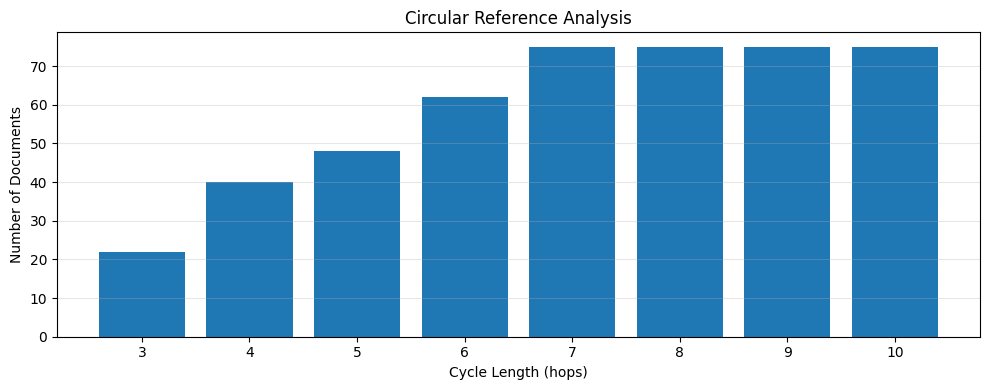

In [61]:
# Analyze cycle lengths - how deep are the cycles?
if driver:
    query = """
    MATCH p=(d:Document)-[:REFERENCES*2..10]->(d)
    WITH length(p) as cycle_len, d
    RETURN cycle_len as cycle_length, count(DISTINCT d) as num_docs_in_cycle
    ORDER BY cycle_len
    """
    results = run_query(driver, query)
    if results:
        df = pd.DataFrame(results)
        print("\nCycle length distribution:")
        print(df.to_string(index=False))
        print(f"\nChart of cycle prevalence:")
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 4))
        plt.bar(df['cycle_length'].astype(str), df['num_docs_in_cycle'])
        plt.xlabel('Cycle Length (hops)')
        plt.ylabel('Number of Documents')
        plt.title('Circular Reference Analysis')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No cycles found")

In [62]:
# Classify cycles by severity - bounded to 8 hops
if driver:
    query = """
    MATCH p=(d:Document)-[:REFERENCES*2..8]->(d)
    WITH d, length(p) as len
    RETURN 
        CASE 
            WHEN len = 2 THEN 'SHORT (2-hop)'
            WHEN len >= 3 AND len <= 4 THEN 'MEDIUM (3-4 hop)'
            ELSE 'LONG (5+ hop)'
        END as cycle_class,
        count(DISTINCT d) as count
    ORDER BY cycle_class, count DESC
    """
    results = run_query(driver, query)
    if results:
        df = pd.DataFrame(results)
        print("\nCycle severity classification:")
        print(df.to_string(index=False))
    else:
        print("No cycles to classify")


Cycle severity classification:
     cycle_class  count
   LONG (5+ hop)     77
MEDIUM (3-4 hop)     47


In [63]:
# Show full cycle paths (the actual documents involved)
if driver:
    query = """
    MATCH p=(start:Document)-[:REFERENCES*2..5]->(start)
    WHERE start.document_id IN ['DOC_0001','DOC_0005','DOC_0010']
    RETURN 
        start.document_id as starting_doc,
        [n IN nodes(p) | n.document_id] as full_cycle_path,
        length(p) as cycle_length
    LIMIT 10
    """
    results = run_query(driver, query)
    print("\nActual cycle paths (example documents):")
    if results:
        for i, r in enumerate(results):
            print(f"\n{i+1}. Starting from {r['starting_doc']} (cycle length: {r['cycle_length']})")
            print(f"   Path: {' → '.join(r['full_cycle_path'])} → {r['starting_doc']} (back to start)")
    else:
        print("No cycles found in selected documents")


Actual cycle paths (example documents):

1. Starting from DOC_0001 (cycle length: 4)
   Path: DOC_0001 → DOC_0058 → DOC_0063 → DOC_0096 → DOC_0001 → DOC_0001 (back to start)

2. Starting from DOC_0001 (cycle length: 5)
   Path: DOC_0001 → DOC_0058 → DOC_0063 → DOC_0019 → DOC_0039 → DOC_0001 → DOC_0001 (back to start)

3. Starting from DOC_0001 (cycle length: 3)
   Path: DOC_0001 → DOC_0058 → DOC_0039 → DOC_0001 → DOC_0001 (back to start)

4. Starting from DOC_0001 (cycle length: 4)
   Path: DOC_0001 → DOC_0034 → DOC_0052 → DOC_0096 → DOC_0001 → DOC_0001 (back to start)

5. Starting from DOC_0001 (cycle length: 5)
   Path: DOC_0001 → DOC_0016 → DOC_0090 → DOC_0062 → DOC_0096 → DOC_0001 → DOC_0001 (back to start)

6. Starting from DOC_0001 (cycle length: 5)
   Path: DOC_0001 → DOC_0016 → DOC_0090 → DOC_0048 → DOC_0039 → DOC_0001 → DOC_0001 (back to start)

7. Starting from DOC_0001 (cycle length: 5)
   Path: DOC_0001 → DOC_0016 → DOC_0090 → DOC_0008 → DOC_0088 → DOC_0001 → DOC_0001 (bac

In [64]:
# Data quality report - check cycles up to 8 hops
if driver:
    query = """
    MATCH (all:Document)
    WITH count(all) as total
    MATCH (cycled:Document) WHERE (cycled)-[:REFERENCES*2..8]->(cycled)
    RETURN 
        total as total_documents,
        count(DISTINCT cycled) as docs_in_cycles,
        round(100.0*count(DISTINCT cycled)/total, 1) as percent_in_cycles
    """
    result = run_query(driver, query)[0]
    print("\n=== DATA QUALITY REPORT ===")
    print(f"Total documents: {result['total_documents']}")
    print(f"Documents in cycles: {result['docs_in_cycles']} ({result['percent_in_cycles']}%)")
    if result['percent_in_cycles'] > 10:
        print("⚠ WARNING: High percentage of documents in cycles - investigate!")
    else:
        print("✓ Good: Most documents are cycle-free")


=== DATA QUALITY REPORT ===
Total documents: 100
Documents in cycles: 77 (77.0%)
⚠ WARNING: High percentage of documents in cycles - investigate!


In [65]:
# QUICK EXERCISE 3: Find the shortest cycle
# Return: minimum cycle length, how many documents are in a cycle of that length

print("EXERCISE 3: Shortest cycle analysis\n")
print("Find the shortest cycle in the graph and count documents involved.\n")

if driver:
    # SOLUTION:
    query = """
    MATCH p=(d:Document)-[:REFERENCES*2..8]->(d)
    WITH length(p) as cycle_len
    WITH min(cycle_len) as min_cycle_length
    MATCH p2=(d2:Document)-[:REFERENCES*2..8]->(d2)
    WHERE length(p2) = min_cycle_length
    RETURN 
        min_cycle_length as shortest_cycle_length,
        count(DISTINCT d2) as num_docs_in_shortest_cycle,
        collect(DISTINCT d2.document_id) as example_docs
    """
    result = run_query(driver, query)
    if result:
        r = result[0]
        print("Solution:")
        print(f"Shortest cycle length: {r['shortest_cycle_length']} hops")
        print(f"Documents in shortest cycle: {r['num_docs_in_shortest_cycle']}")
        print(f"Examples: {r['example_docs'][:5]}")
    else:
        print("No cycles found")

EXERCISE 3: Shortest cycle analysis

Find the shortest cycle in the graph and count documents involved.

Solution:
Shortest cycle length: 3 hops
Documents in shortest cycle: 22
Examples: ['DOC_0001', 'DOC_0008', 'DOC_0012', 'DOC_0016', 'DOC_0019']


---
# Part 4: Path Aggregation with reduce()

## Concept: Aggregating Values Along Paths

The `reduce()` function aggregates values (sum, min, max) across all items in a path:

```cypher
reduce(accumulator = initial_value, item IN collection | expression)
```

**Examples**:
- Sum weights: `reduce(sum=0, r IN relationships(p) | sum + r.weight)`
- Count hops: `reduce(count=0, n IN nodes(p) | count + 1)` (or just use `length(p)`)
- Find max: `reduce(max=0, r IN relationships(p) | CASE WHEN r.latency > max THEN r.latency ELSE max END)`

**Real-world use**: Cost calculation, latency, risk scoring, approval count.

In [66]:
# Simple weight summation along path
if driver:
    query = """
    MATCH p=(d1:Document {document_id: 'DOC_0001'})-[rels:REFERENCES*1..3]->(d2:Document)
    RETURN 
        d2.document_id as target,
        length(p) as path_hops,
        reduce(weight_sum=0, r IN relationships(p) | weight_sum + r.weight) as total_weight,
        [r IN relationships(p) | r.weight] as individual_weights
    ORDER BY total_weight DESC
    LIMIT 15
    """
    results = run_query(driver, query)
    df = pd.DataFrame(results)
    print("Paths from DOC_0001 with cumulative reference weights:")
    print(df.to_string(index=False))

Paths from DOC_0001 with cumulative reference weights:
  target  path_hops  total_weight individual_weights
DOC_0057          3            12          [4, 4, 4]
DOC_0085          3            11          [4, 4, 3]
DOC_0082          3            11          [4, 4, 3]
DOC_0084          3            11          [4, 4, 3]
DOC_0096          3            11          [4, 3, 4]
DOC_0070          3             9          [1, 3, 5]
DOC_0083          3             9          [4, 4, 1]
DOC_0087          3             9          [4, 4, 1]
DOC_0086          3             9          [4, 4, 1]
DOC_0090          3             9          [4, 1, 4]
DOC_0046          3             9          [4, 4, 1]
DOC_0082          3             8          [2, 2, 4]
DOC_0069          3             8          [4, 1, 3]
DOC_0081          2             8             [4, 4]
DOC_0019          3             8          [2, 2, 4]


In [67]:
# Find minimum-cost path between documents
if driver:
    query = """
    MATCH p=(d1:Document {document_id: 'DOC_0010'})-[:REFERENCES*1..4]->(d2:Document)
    WHERE d2.document_id STARTS WITH 'DOC_002'
    RETURN 
        d1.document_id + ' -> ' + d2.document_id as path_pair,
        [n IN nodes(p) | n.document_id] as node_sequence,
        reduce(w=0, r IN relationships(p) | w + r.weight) as total_cost,
        length(p) as num_hops
    ORDER BY total_cost ASC
    LIMIT 10
    """
    results = run_query(driver, query)
    if results:
        print("\nPaths ordered by total weight (lowest cost first):")
        for i, r in enumerate(results[:5]):
            print(f"\n{i+1}. {r['path_pair']} (cost: {r['total_cost']}, {r['num_hops']} hops)")
            print(f"   Route: {' -> '.join(r['node_sequence'])}")


Paths ordered by total weight (lowest cost first):

1. DOC_0010 -> DOC_0020 (cost: 6, 2 hops)
   Route: DOC_0010 -> DOC_0019 -> DOC_0020

2. DOC_0010 -> DOC_0023 (cost: 8, 4 hops)
   Route: DOC_0010 -> DOC_0019 -> DOC_0090 -> DOC_0048 -> DOC_0023

3. DOC_0010 -> DOC_0024 (cost: 8, 3 hops)
   Route: DOC_0010 -> DOC_0019 -> DOC_0020 -> DOC_0024

4. DOC_0010 -> DOC_0024 (cost: 10, 4 hops)
   Route: DOC_0010 -> DOC_0019 -> DOC_0090 -> DOC_0044 -> DOC_0024

5. DOC_0010 -> DOC_0028 (cost: 10, 3 hops)
   Route: DOC_0010 -> DOC_0069 -> DOC_0071 -> DOC_0028


In [68]:
# Path analysis with multiple aggregations
if driver:
    query = """
    MATCH p=(start:Document)-[:REFERENCES*2..4]->(end:Document)
    WHERE start.document_id='DOC_0015'
    WITH end, length(p) as path_length, relationships(p) as rels
    RETURN 
        end.document_id as target,
        path_length as num_hops,
        reduce(sum_w=0, r IN rels | sum_w + r.weight) as total_weight,
        round(reduce(sum_w=0, r IN rels | sum_w + r.weight)*1.0 / path_length, 2) as avg_weight_per_hop
    ORDER BY total_weight DESC
    LIMIT 10
    """
    results = run_query(driver, query)
    df = pd.DataFrame(results)
    print("\nPath efficiency analysis (total weight vs average weight per hop):")
    print(df.to_string(index=False))


Path efficiency analysis (total weight vs average weight per hop):
  target  num_hops  total_weight  avg_weight_per_hop
DOC_0075         4            14                3.50
DOC_0062         4            14                3.50
DOC_0043         4            14                3.50
DOC_0058         4            13                3.25
DOC_0084         4            13                3.25
DOC_0018         4            13                3.25
DOC_0080         4            13                3.25
DOC_0069         4            13                3.25
DOC_0012         4            12                3.00
DOC_0032         4            12                3.00


In [69]:
# Approval chain analysis (simple aggregation of chain length)
if driver:
    query = """
    MATCH p=(d:Document)-[:OWNED_BY]->(o:Owner)
    WITH d, o, [n IN nodes(p) | COALESCE(n.name, n.document_id)] as approval_chain, length(p) as num_approvers
    RETURN 
        d.document_id as document,
        approval_chain as approver_chain,
        num_approvers as chain_length
    ORDER BY num_approvers DESC
    LIMIT 10
    """
    results = run_query(driver, query)
    print("\nApproval chains (document to owner):")
    for r in results:
        print(f"{r['document']}: {' -> '.join(str(x) for x in r['approver_chain'])} ({r['chain_length']} hops)")


Approval chains (document to owner):
DOC_0098: Set - Building -> Allison Hill (1 hops)
DOC_0089: Product - Collection -> Allison Hill (1 hops)
DOC_0085: Mr - Minute -> Allison Hill (1 hops)
DOC_0081: Pattern - Later -> Allison Hill (1 hops)
DOC_0072: Forward - Difference -> Allison Hill (1 hops)
DOC_0057: Election - Common -> Allison Hill (1 hops)
DOC_0035: Old - Finally -> Allison Hill (1 hops)
DOC_0031: Animal - Show -> Allison Hill (1 hops)
DOC_0021: Sure - Collection -> Allison Hill (1 hops)
DOC_0015: Rate - Science -> Allison Hill (1 hops)


In [70]:
# Critical path detection (high-weight routes)
if driver:
    query = """
    MATCH p=(d1:Document)-[:REFERENCES*1..5]->(d2:Document)
    WITH d1, d2, reduce(w=0, r IN relationships(p) | w + r.weight) as total_weight, length(p) as hops
    WHERE total_weight >= 6
    RETURN 
        d1.document_id as source,
        d2.document_id as target,
        total_weight as path_weight,
        hops as hops,
        'CRITICAL' as risk_level
    ORDER BY total_weight DESC
    LIMIT 15
    """
    results = run_query(driver, query)
    df = pd.DataFrame(results)
    print("\nCritical paths (high cumulative weight):")
    print(df.to_string(index=False))


Critical paths (high cumulative weight):
  source   target  path_weight  hops risk_level
DOC_0067 DOC_0075           23     5   CRITICAL
DOC_0071 DOC_0075           23     5   CRITICAL
DOC_0066 DOC_0075           23     5   CRITICAL
DOC_0067 DOC_0075           22     5   CRITICAL
DOC_0067 DOC_0075           22     5   CRITICAL
DOC_0067 DOC_0074           22     5   CRITICAL
DOC_0066 DOC_0074           22     5   CRITICAL
DOC_0066 DOC_0072           22     5   CRITICAL
DOC_0066 DOC_0070           22     5   CRITICAL
DOC_0066 DOC_0072           22     5   CRITICAL
DOC_0067 DOC_0073           22     5   CRITICAL
DOC_0067 DOC_0075           22     5   CRITICAL
DOC_0067 DOC_0062           22     5   CRITICAL
DOC_0067 DOC_0043           22     5   CRITICAL
DOC_0066 DOC_0074           22     5   CRITICAL


In [71]:
# QUICK EXERCISE 4: High-value path pairs
# Find the pair of documents (starting with DOC_00*) with highest total reference weight

print("EXERCISE 4: Highest-weight path discovery\n")
print("Find the pair of documents (source starts with 'DOC_00') with highest total weight.")
print("Consider all paths up to 4 hops.\n")

if driver:
    # SOLUTION:
    query = """
    MATCH p=(source:Document)-[:REFERENCES*1..4]->(target:Document)
    WHERE source.document_id STARTS WITH 'DOC_00'
    WITH source, target, reduce(w=0, r IN relationships(p) | w + r.weight) as total_weight, count(*) as num_paths
    RETURN 
        source.document_id as source_doc,
        target.document_id as target_doc,
        total_weight as max_cumulative_weight,
        num_paths as num_different_paths
    ORDER BY total_weight DESC
    LIMIT 5
    """
    results = run_query(driver, query)
    df = pd.DataFrame(results)
    print("Solution (top 5 highest-weight pairs):")
    print(df.to_string(index=False))

EXERCISE 4: Highest-weight path discovery

Find the pair of documents (source starts with 'DOC_00') with highest total weight.
Consider all paths up to 4 hops.

Solution (top 5 highest-weight pairs):
source_doc target_doc  max_cumulative_weight  num_different_paths
  DOC_0067   DOC_0072                     18                    1
  DOC_0067   DOC_0074                     18                    1
  DOC_0066   DOC_0075                     18                    1
  DOC_0066   DOC_0070                     18                    1
  DOC_0067   DOC_0075                     18                    5


---
# Part 5: Query Performance & Optimization

## Understanding Query Performance

Two tools for analyzing query execution:

1. **EXPLAIN** - Shows planned execution (estimated costs before running)
   - Predicts which indexes will be used
   - Shows estimated row counts
   - Fast (doesn't execute the query)

2. **PROFILE** - Shows actual execution (measured performance)
   - Actual row counts and times
   - Identifies unexpected hot spots
   - Slower (executes the full query)

**Key metrics**:
- `dbHits` - How many database lookups
- `rows` - How many rows processed
- Time - Total execution time

**Rule of thumb**: Indexed lookups are 100-1000x faster than full table scans.

In [72]:
# EXPLAIN: Show query plan (estimated)
if driver:
    print("Query Plan Analysis (EXPLAIN):\n")
    print("1. Indexed lookup (document_id is a constraint):")
    print("   MATCH (d:Document {document_id: 'DOC_0001'})-[:REFERENCES*1..5]->(d2)")
    print("   → Uses index on document_id (very fast)\n")
    
    print("2. Filter without index (status is NOT a constraint):")
    print("   MATCH (d:Document {status: 'active'})-[:REFERENCES*1..5]->(d2)")
    print("   → Must scan ALL documents, then filter (slower)\n")
    
    print("✓ TIP: Always filter on indexed properties first!")

Query Plan Analysis (EXPLAIN):

1. Indexed lookup (document_id is a constraint):
   MATCH (d:Document {document_id: 'DOC_0001'})-[:REFERENCES*1..5]->(d2)
   → Uses index on document_id (very fast)

2. Filter without index (status is NOT a constraint):
   MATCH (d:Document {status: 'active'})-[:REFERENCES*1..5]->(d2)
   → Must scan ALL documents, then filter (slower)

✓ TIP: Always filter on indexed properties first!


In [73]:
# PROFILE: Show actual execution metrics
if driver:
    query = """
    PROFILE MATCH p=(d:Document)-[:REFERENCES*2..4]->(d2)
    WHERE d.document_id='DOC_0001'
    RETURN count(p) as num_paths
    """
    with driver.session() as session:
        result = session.run(query)
        records = list(result)
        summary = result.consume()
        print("PROFILE Results:")
        print(f"Time to first record: {summary.result_available_after} ms")
        print(f"Time to consume all: {summary.result_consumed_after} ms")
        if records:
            print(f"\nQuery result:")
            for rec in records:
                print(f"  {dict(rec)}")

PROFILE Results:
Time to first record: 1 ms
Time to consume all: 0 ms

Query result:
  {'num_paths': 178}


In [74]:
# Performance best practices
print("\n=== PERFORMANCE BEST PRACTICES ===")
print("\n1. Use bounds on variable-length paths:")
print("   ✓ GOOD:  (d)-[:REFERENCES*1..5]->(d2)")
print("   ✗ BAD:   (d)-[:REFERENCES*]->(d2)  -- can traverse infinitely\n")

print("2. Filter early with indexed properties:")
print("   ✓ GOOD:  WHERE d.document_id = 'DOC_0001'")
print("   ✗ BAD:   WHERE d.status = 'active'  -- might require full scan\n")

print("3. Use specific relationship types:")
print("   ✓ GOOD:  [:REFERENCES]->(d2)")
print("   ✗ BAD:   -[]->(d2)  -- traverses all relationship types\n")

print("4. Limit results when exploring:")
print("   ✓ GOOD:  RETURN ... LIMIT 100")
print("   ✗ BAD:   RETURN ... LIMIT 1000000\n")

print("5. Project before aggregating (when possible):")
print("   ✓ GOOD:  WITH ..select minimal columns...")
print("   ✗ BAD:   RETURN * with full nodes\n")


=== PERFORMANCE BEST PRACTICES ===

1. Use bounds on variable-length paths:
   ✓ GOOD:  (d)-[:REFERENCES*1..5]->(d2)
   ✗ BAD:   (d)-[:REFERENCES*]->(d2)  -- can traverse infinitely

2. Filter early with indexed properties:
   ✓ GOOD:  WHERE d.document_id = 'DOC_0001'
   ✗ BAD:   WHERE d.status = 'active'  -- might require full scan

3. Use specific relationship types:
   ✓ GOOD:  [:REFERENCES]->(d2)
   ✗ BAD:   -[]->(d2)  -- traverses all relationship types

4. Limit results when exploring:
   ✓ GOOD:  RETURN ... LIMIT 100
   ✗ BAD:   RETURN ... LIMIT 1000000

5. Project before aggregating (when possible):
   ✓ GOOD:  WITH ..select minimal columns...
   ✗ BAD:   RETURN * with full nodes



---
# Capstone: Student Exercises

## EXERCISE 1: Complex Approval Path Analysis

**Scenario**: Trace all possible approval workflows for a document as it moves through the organization.

**Task**: Find all paths from a specific document through its owner(s) to team(s). Calculate:
1. Total steps in path (hops)
2. All intermediate nodes
3. Classify path as "efficient" (≤3 steps) or "complex" (>3 steps)

**Return columns**: document_id, path_sequence, step_count, efficiency_rating

**Hint**: Use `(document)-[:OWNED_BY]->(owner)-[:works_in?]->(team)` or similar traversal

In [75]:
print("EXERCISE 1: Approval workflow analysis\n")
print("Find all paths from a document through owners to teams.")
print("Classify each path as efficient (≤3 hops) or complex (>3 hops).\n")

if driver:
    # SOLUTION:
    query = """
    MATCH p=(d:Document {document_id: 'DOC_0001'})-[:OWNED_BY]->(o:Owner)
    RETURN 
        d.document_id as document,
        [n IN nodes(p) | COALESCE(n.name, n.document_id)] as approval_path,
        length(p) as step_count,
        CASE WHEN length(p) <= 3 THEN 'EFFICIENT' ELSE 'COMPLEX' END as classification
    """
    results = run_query(driver, query)
    print("Solution - Approval paths for DOC_0001:")
    for r in results:
        print(f"\nDocument: {r['document']}")
        print(f"Path: {' → '.join(str(x) for x in r['approval_path'])}")
        print(f"Steps: {r['step_count']} | Classification: {r['classification']}")

EXERCISE 1: Approval workflow analysis

Find all paths from a document through owners to teams.
Classify each path as efficient (≤3 hops) or complex (>3 hops).

Solution - Approval paths for DOC_0001:

Document: DOC_0001
Path: Purpose - Brother → Shannon Ray
Steps: 1 | Classification: EFFICIENT


## EXERCISE 2: Circular Reference Risk Report

**Scenario**: Audit documents for circular dependencies and classify risk level.

**Task**: For each document involved in a cycle:
1. Count how many cycles it participates in
2. Find the shortest cycle length
3. Classify risk as:
   - "HIGH_RISK" if min cycle length is 2-3
   - "MEDIUM_RISK" if min cycle length is 4-5
   - "LOW_RISK" if min cycle length is 6+

**Return columns**: document_id, num_cycles, min_cycle_length, risk_level

**Hint**: Combine cycle detection with CASE statement for risk classification

In [ ]:
print("EXERCISE 2: Circular reference risk classification\n")
print("Identify documents in cycles and classify by risk level.\n")

if driver:
    # SOLUTION:
    query = """
    MATCH p=(d:Document)-[:REFERENCES*2..8]->(d)
    WITH d, length(p) as cycle_len, count(*) as num_cycle_instances
    WITH d, min(cycle_len) as min_cycle_length, count(DISTINCT cycle_len) as num_different_cycles
    RETURN 
        d.document_id as document,
        num_different_cycles as num_cycle_types,
        min_cycle_length as shortest_cycle,
        CASE 
            WHEN min_cycle_length <= 3 THEN 'HIGH_RISK'
            WHEN min_cycle_length <= 5 THEN 'MEDIUM_RISK'
            ELSE 'LOW_RISK'
        END as risk_level
    ORDER BY risk_level DESC, min_cycle_length ASC
    """
    results = run_query(driver, query)
    if results:
        df = pd.DataFrame(results)
        print("Solution - Risk assessment:")
        print(df.to_string(index=False))
        
        # Summary
        high_risk = len([r for r in results if r['risk_level'] == 'HIGH_RISK'])
        print(f"\n⚠ HIGH_RISK documents that need attention: {high_risk}")
    else:
        print("No documents in cycles")

EXERCISE 2: Circular reference risk classification

Identify documents in cycles and classify by risk level.



---
## Summary: Key Learnings

### Path Query Patterns Mastered
1. **Named paths**: `p = (a)-[]->(b)` with `nodes(p)`, `relationships(p)`, `length(p)`
2. **Variable-length**: `-[*1..3]->` for exploring neighborhoods
3. **Cycle detection**: `(d)-[*2..]->(d)` for self-references
4. **Aggregation**: `reduce(sum=0, r IN relationships(p) | sum + r.weight)`
5. **Performance**: Always use bounds, filter early, profile expensive queries

### Real-World Applications
- 🔍 **Approval chains**: Document → Owner → Team
- ⚠️ **Risk analysis**: Detect circular dependencies
- 📊 **Cost calculation**: Sum weights along least-cost paths
- 🎯 **Recommendations**: Find similar users through shared paths
- 🔧 **System dependencies**: Trace impact of component failure

### Next Lesson: Neo4j GDS Workflow
In Lesson 11, we'll use these path concepts at scale with Graph Data Science algorithms!